# DEMO 3 — 47 都道府県 定員充足率ヒートマップ

## 分析前チェックリスト

- **問い**: 全国平均で語れない **地域格差** はどこにどれくらいあるか？
- **予想**: 地方の小規模私大は深刻、都心 (東京・愛知・沖縄) は比較的堅調
- **反証条件**: 全都道府県が均一に苦しんでいれば "地域格差" の枠組みは誤り
- **出典**: 私学事業団 2025 志願動向 / e-Stat 地域別将来推計人口

> ⚠️ **重要**: 本 Notebook で使用する充足率は**講演デモ用の近似値**です。
> 実際の政策判断には一次資料（私学事業団年報・e-Stat）を必ずご参照ください。


In [1]:
import pandas as pd

# デモ用近似値: 47 都道府県の私立大定員充足率 (%)
# 傾向: 東京・愛知・沖縄 = 緑寄り (>=100%)、東北・四国・山陰 = 赤寄り (<90%)
# 出典目安: 私学事業団 令和 7 年度 志願動向 (2025) — 数値は説明用に丸めた近似値
pref_data = {
    "北海道": 92, "青森県": 82, "岩手県": 84, "宮城県": 96, "秋田県": 78,
    "山形県": 83, "福島県": 88, "茨城県": 94, "栃木県": 93, "群馬県": 95,
    "埼玉県": 101, "千葉県": 102, "東京都": 108, "神奈川県": 105, "新潟県": 89,
    "富山県": 91, "石川県": 97, "福井県": 90, "山梨県": 92, "長野県": 90,
    "岐阜県": 94, "静岡県": 97, "愛知県": 104, "三重県": 93, "滋賀県": 99,
    "京都府": 103, "大阪府": 105, "兵庫県": 100, "奈良県": 96, "和歌山県": 87,
    "鳥取県": 79, "島根県": 80, "岡山県": 95, "広島県": 98, "山口県": 86,
    "徳島県": 82, "香川県": 88, "愛媛県": 85, "高知県": 81, "福岡県": 102,
    "佐賀県": 89, "長崎県": 90, "熊本県": 93, "大分県": 88, "宮崎県": 86,
    "鹿児島県": 89, "沖縄県": 104,
}
df3 = pd.DataFrame({"prefecture": list(pref_data.keys()),
                    "juten_ritsu_pct": list(pref_data.values())})
print(f"N = {len(df3)} 都道府県")
print(f"平均: {df3['juten_ritsu_pct'].mean():.1f}%  中央値: {df3['juten_ritsu_pct'].median():.1f}%")
print(f"最大: {df3['juten_ritsu_pct'].max()}% ({df3.loc[df3['juten_ritsu_pct'].idxmax(), 'prefecture']})")
print(f"最小: {df3['juten_ritsu_pct'].min()}% ({df3.loc[df3['juten_ritsu_pct'].idxmin(), 'prefecture']})")
df3.head(10)

N = 47 都道府県
平均: 92.4%  中央値: 92.0%
最大: 108% (東京都)
最小: 78% (秋田県)


,prefecture,juten_ritsu_pct
0,北海道,92
1,青森県,82
2,岩手県,84
3,宮城県,96
4,秋田県,78
5,山形県,83
6,福島県,88
7,茨城県,94
8,栃木県,93
9,群馬県,95


/tmp/ipykernel_1688588/1753279268.py:47: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) IPAexGothic.
  fig.savefig(f"{OUT_DIR}/demo03_pref_heatmap.png", dpi=140, bbox_inches="tight")
/tmp/ipykernel_1688588/1753279268.py:47: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) IPAexGothic.
  fig.savefig(f"{OUT_DIR}/demo03_pref_heatmap.png", dpi=140, bbox_inches="tight")
/home/nahisaho/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nahisaho/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


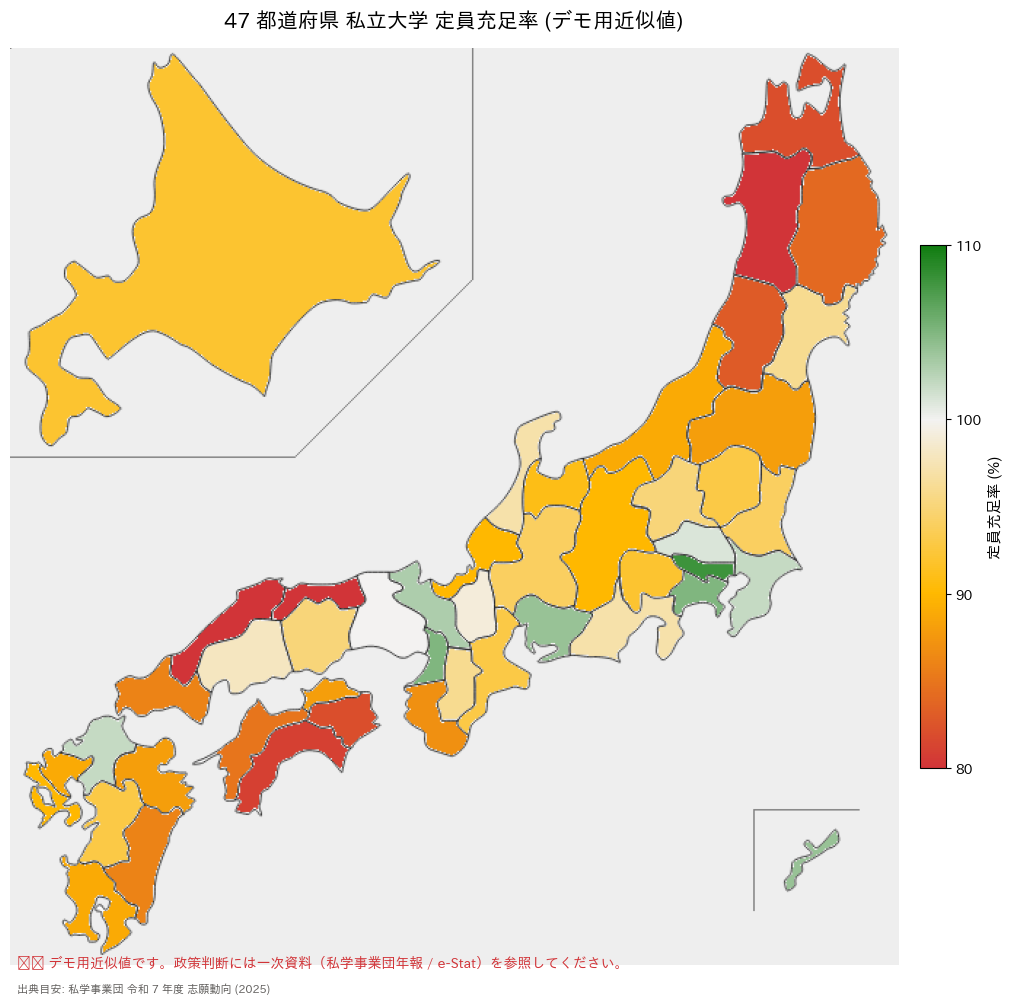

saved: ../assets/demo03_pref_heatmap.png


In [2]:
import os
import matplotlib.pyplot as plt
import japanize_matplotlib
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from japanmap import picture, pref_names

OUT_DIR = "../assets"
os.makedirs(OUT_DIR, exist_ok=True)

# カラースケール: 赤 (80%) → 橙 (90%) → 白 (100%) → 緑 (110%)
cmap = LinearSegmentedColormap.from_list(
    "fuel", ["#D13438", "#FFB900", "#F3F2F1", "#107C10"], N=256
)
norm = Normalize(vmin=80, vmax=110)

# japanmap は prefectures を コード (1=北海道 ... 47=沖縄) で持つ
pref_color = {}
for i, pname in enumerate(pref_names[1:], start=1):  # pref_names[0] は "_"
    val = pref_data[pname]
    rgba = cmap(norm(val))
    # 0-255 の RGB タプルに
    pref_color[i] = tuple(int(c * 255) for c in rgba[:3])

fig, ax = plt.subplots(figsize=(11, 10))
ax.imshow(picture(pref_color))
ax.set_axis_off()
ax.set_title("47 都道府県 私立大学 定員充足率 (デモ用近似値)",
             fontsize=15, fontweight="bold", pad=15)

# カラーバー
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", shrink=0.55, pad=0.02)
cbar.set_label("定員充足率 (%)", fontsize=11)
cbar.set_ticks([80, 90, 100, 110])

# 注記
fig.text(0.02, 0.03,
         "⚠️ デモ用近似値です。政策判断には一次資料（私学事業団年報 / e-Stat）を参照してください。",
         fontsize=10, color="#D13438")
fig.text(0.02, 0.005,
         "出典目安: 私学事業団 令和 7 年度 志願動向 (2025)",
         fontsize=8, color="#605E5C")

plt.tight_layout()
fig.savefig(f"{OUT_DIR}/demo03_pref_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved: {OUT_DIR}/demo03_pref_heatmap.png")

In [3]:
print("="*60)
print("DEMO 3 — 予想との差分レポート")
print("="*60)

# 都心 (東京・愛知・沖縄)
tomari = ["東京都", "愛知県", "沖縄県"]
tomari_avg = df3[df3["prefecture"].isin(tomari)]["juten_ritsu_pct"].mean()

# 地方の "深刻" 想定県 (東北・四国・山陰)
chihou = ["秋田県", "青森県", "岩手県", "山形県",  # 東北
          "徳島県", "香川県", "愛媛県", "高知県",  # 四国
          "鳥取県", "島根県", "山口県"]           # 山陰・中国西部
chihou_avg = df3[df3["prefecture"].isin(chihou)]["juten_ritsu_pct"].mean()

print(f"\n【予想】 地方の小規模私大は深刻 (<90%)、都心は比較的堅調 (>=100%)")
print(f"        反証条件: 全都道府県が均一なら 地域格差 の枠組みは誤り\n")

print(f"【実測 (デモ用近似値)】")
print(f"  全国平均: {df3['juten_ritsu_pct'].mean():.1f}%")
print(f"  都心 (東京・愛知・沖縄) 平均: {tomari_avg:.1f}%")
print(f"  地方 (東北・四国・山陰) 平均: {chihou_avg:.1f}%")
print(f"  格差 (都心 - 地方): {tomari_avg - chihou_avg:.1f}pt\n")

print(f"【予想通り】")
print(f"  ✅ 地方の充足率低下 (東北・四国・山陰 平均 {chihou_avg:.1f}%)")

print(f"\n【予想外 (反例)】")
top3 = df3.nlargest(3, "juten_ritsu_pct")
print(f"  ⚠️ 都心はむしろ 100% 超え (定員以上に集まっている):")
for _, row in top3.iterrows():
    print(f"     - {row['prefecture']}: {row['juten_ritsu_pct']}%")

print(f"\n【得られた新しい理解】")
print(f"  × 誤: 「日本全体が沈む」")
print(f"  ○ 正: 「集中化と過疎化が同時進行」({tomari_avg - chihou_avg:.1f}pt の格差)")

print(f"\n【反証条件の判定】")
std = df3["juten_ritsu_pct"].std()
print(f"  47 都道府県の充足率 標準偏差: {std:.2f}pt")
print(f"  → 標準偏差 {std:.1f}pt は "'均一' " ではない → 地域格差の枠組みは有効")

print("\n※ 数値は講演デモ用近似値。政策判断には一次資料 (私学事業団年報) を必ず参照。")

DEMO 3 — 予想との差分レポート

【予想】 地方の小規模私大は深刻 (<90%)、都心は比較的堅調 (>=100%)
        反証条件: 全都道府県が均一なら 地域格差 の枠組みは誤り

【実測 (デモ用近似値)】
  全国平均: 92.4%
  都心 (東京・愛知・沖縄) 平均: 105.3%
  地方 (東北・四国・山陰) 平均: 82.5%
  格差 (都心 - 地方): 22.8pt

【予想通り】
  ✅ 地方の充足率低下 (東北・四国・山陰 平均 82.5%)

【予想外 (反例)】
  ⚠️ 都心はむしろ 100% 超え (定員以上に集まっている):
     - 東京都: 108%
     - 神奈川県: 105%
     - 大阪府: 105%

【得られた新しい理解】
  × 誤: 「日本全体が沈む」
  ○ 正: 「集中化と過疎化が同時進行」(22.8pt の格差)

【反証条件の判定】
  47 都道府県の充足率 標準偏差: 7.73pt
  → 標準偏差 7.7pt は 均一 ではない → 地域格差の枠組みは有効

※ 数値は講演デモ用近似値。政策判断には一次資料 (私学事業団年報) を必ず参照。
